# Livrable Final


In [20]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt


## Objectifs


## Opération de débruitage

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


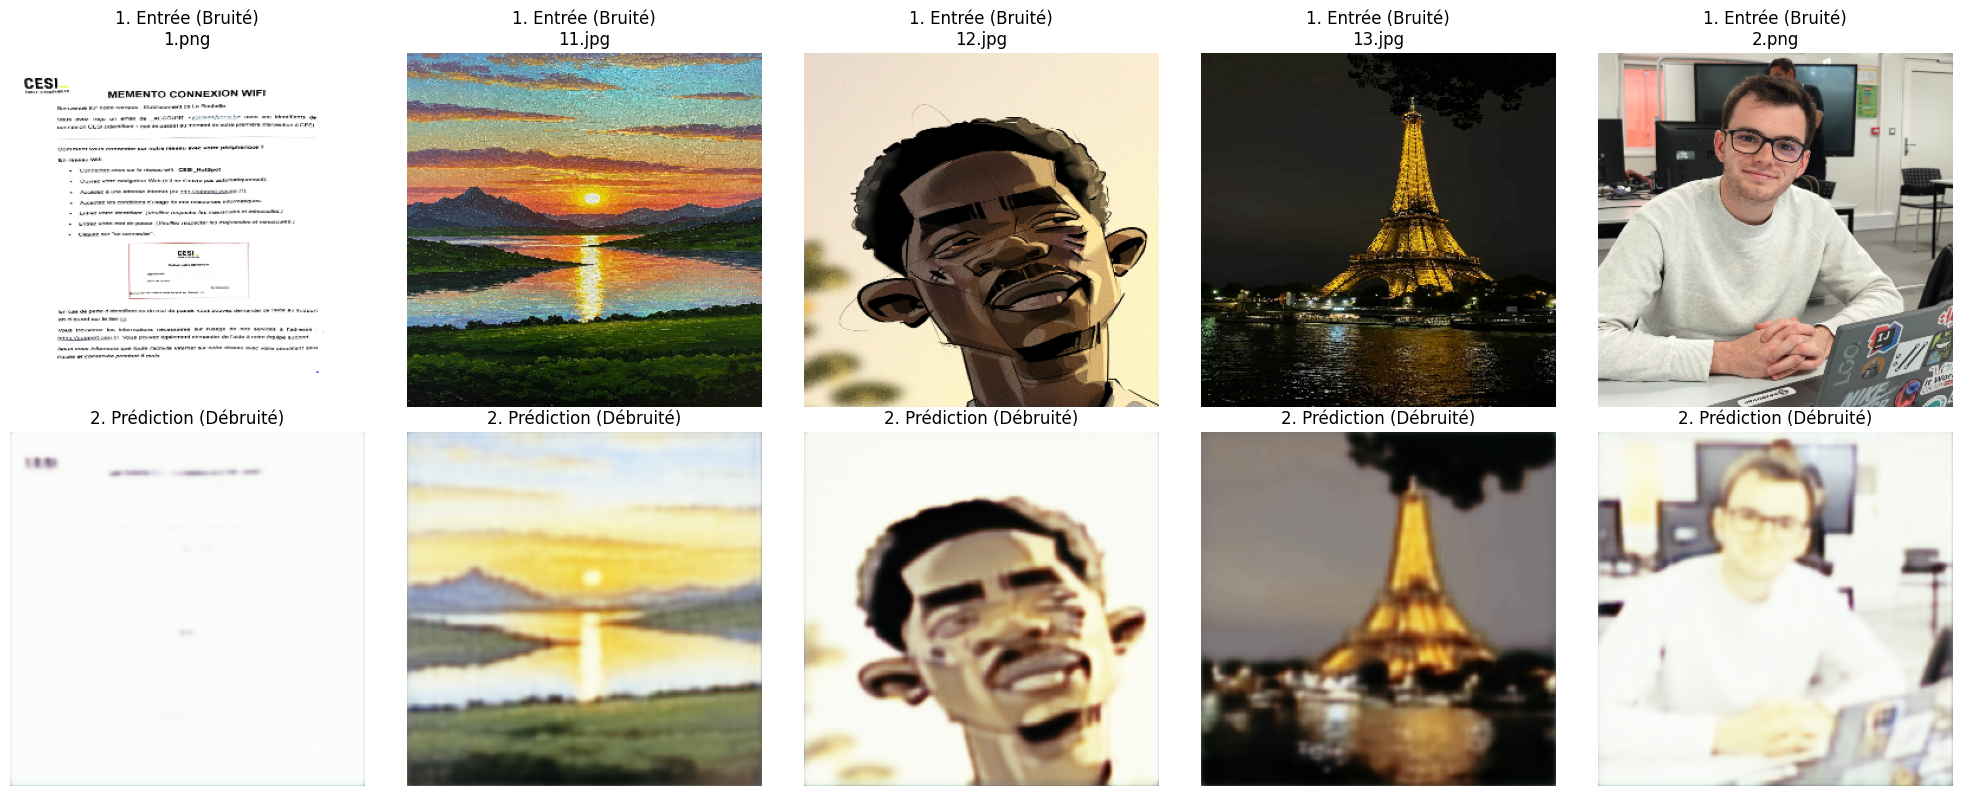

In [21]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt

# 1. Chargement du modèle d'auto-encodeur (denoiser)
model_charge = tf.keras.models.load_model("models/livrable2/autoencoder.keras")

# 2. Préparation des images de datasets/final
img_dir = "datasets/llowfinal"
# On récupère la liste des fichiers images
if not os.path.isdir(img_dir):
    alt_img_dir = "datasets/final"
    if os.path.isdir(alt_img_dir):
        img_dir = alt_img_dir
    else:
        raise FileNotFoundError(f"Directory '{img_dir}' not found and fallback '{alt_img_dir}' not found.")

image_files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
if not image_files:
    raise FileNotFoundError(f"No image files found in '{img_dir}'.")
image_paths = [os.path.join(img_dir, f) for f in image_files]

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [300, 300]) # Le modèle a été entraîné sur du 300x300
    img = tf.cast(img, tf.float32) / 255.0  # Normalisation
    return img

# Création du dataset
path_ds = tf.data.Dataset.from_tensor_slices(image_paths)
test_set_noisy = path_ds.map(load_and_preprocess).batch(5)

# 3. Prédiction et visualisation
for images_noisy in test_set_noisy.take(1):

    # L'IA effectue sa prédiction (le nettoyage)
    images_denoised = model_charge.predict(images_noisy)

    n = len(images_noisy)
    plt.figure(figsize=(20, 8))

    for i in range(n):
        # Ligne 1 : Image bruitée donnée en entrée à l'IA
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images_noisy[i].numpy())
        plt.title(f"1. Entrée (Bruité)\n{image_files[i]}")
        plt.axis("off")

        # Ligne 2 : L'image nettoyée par votre Auto-encodeur
        ax = plt.subplot(2, n, i + 1 + n)
        # Les prédictions Keras sortent en float32 [0, 1]
        plt.imshow(images_denoised[i])
        plt.title("2. Prédiction (Débruité)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


## Classification binaire (Photo / pas photo)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


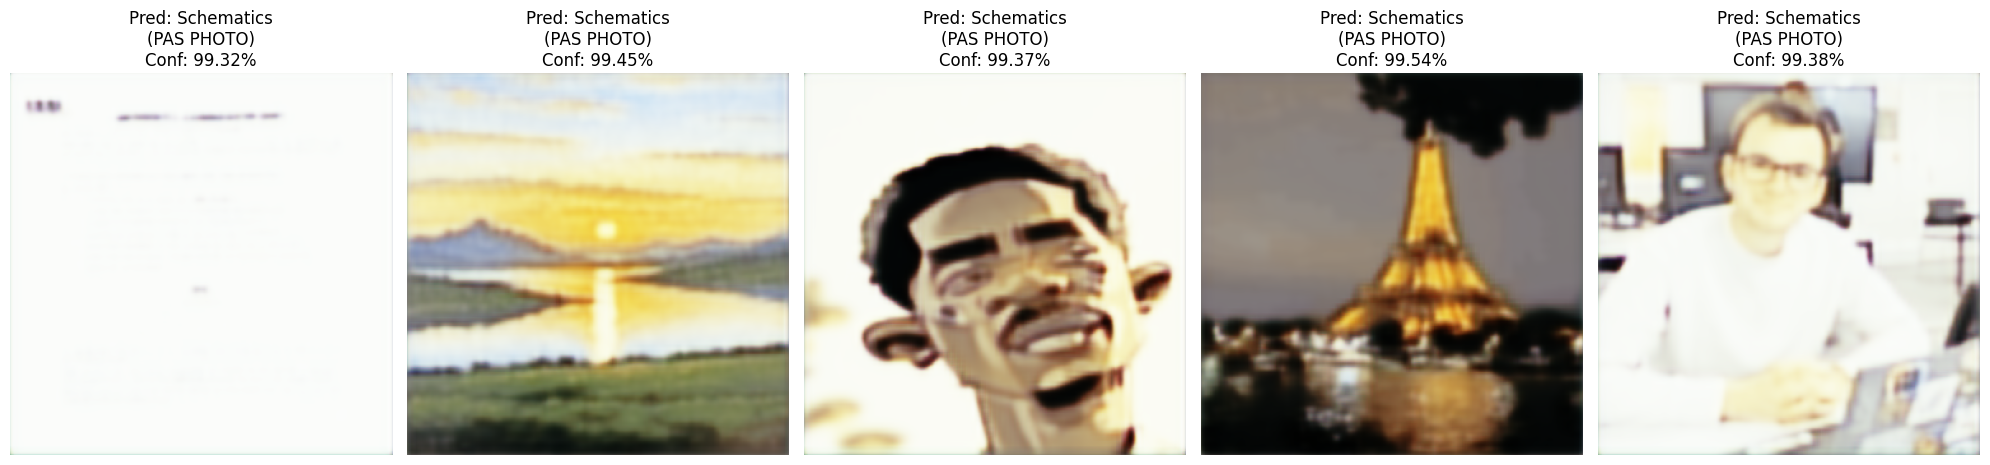

In [23]:
from tensorflow import keras

# 1. Chargement du modèle de classification
classifier_model = keras.models.load_model('models/livrable1/improved_model.keras', compile=False)

# On définit les classes (à adapter selon votre entraînement Livrable 1)
class_names = ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']

# 2. Utilisation des images débruitées de l'étape précédente
images_for_classifier = tf.image.resize(images_denoised, [180, 180])

# 3. Prédiction et application de Softmax pour obtenir les probabilités (confiance)
predictions = classifier_model.predict(images_for_classifier)
score = tf.nn.softmax(predictions)

# 4. Affichage des résultats
plt.figure(figsize=(20, 10))
for i in range(len(images_denoised)):
    ax = plt.subplot(1, len(images_denoised), i + 1)
    plt.imshow(images_denoised[i])
    
    # On utilise score[i] pour obtenir la classe et la confiance
    predicted_class = class_names[np.argmax(score[i])]
    confidence = 100 * np.max(score[i])
    
    # Logique Photo / Pas Photo
    is_photo = "PHOTO" if predicted_class == "Photo" else "PAS PHOTO"
    
    plt.title(f"Pred: {predicted_class}\n({is_photo})\nConf: {confidence:.2f}%")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Captionning